In [115]:
from typing import Annotated
from typing import Literal
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END,StateGraph, START
from langgraph.types import Command
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
from dotenv import load_dotenv

In [116]:
load_dotenv()

True

In [117]:

from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.1-8b-instant")

In [118]:
llm.invoke("hi").content

'How can I assist you today?'

In [119]:
def clean_text(text):
    import re
    clean_text = re.sub(r"<think>.*?</think>\s*", "", text, flags=re.DOTALL)
    return clean_text

In [120]:
clean_text(llm.invoke("hi").content)

'How can I assist you today?'

In [121]:
tavily_tool=TavilySearchResults()

In [122]:
tavily_tool.invoke("what is a gdp?")

[{'title': 'What is GDP?',
  'url': 'https://www.youtube.com/watch?v=_pTkwg6iUV0',
  'content': "[Music] gdp is the best-known three-letter acronym in economics but what exactly is gdp gdp or gross domestic product is the total market value of all final goods and services produced in an economy in a given year it measures the production of goods like pizza new houses cell phones and services like your favorite streaming channels the calculations are simple accounting multiplying the prices of the goods and services by the quantity sold and adding it all up for the entire economy it's important to note that all these goods are measured in the price at which they are sold to the end consumer in u.s dollars because one person's spending is another person's income gdp can be tracked by either adding up income earned from selling goods and services or by tracking spending on goods and [...] goods and services or by tracking spending on goods and services as we'll find out later the spending

In [123]:
code = """
x = 5
y = x * 2
print(y)
"""

In [124]:
repl=PythonREPL()

In [125]:
repl.run(code)

'10\n'

In [126]:
@tool
def python_repl_tool(code:Annotated[str,"The python code to execute to generate your chart."]):

    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""

    try:
        result=repl.run(code)
    except BaseException as e:
        return f"Failed to execute.Error: {repr(e)}"

    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

In [127]:
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x = 5
y = x * 2
print(y)

\`\`\`
Stdout: 10



In [128]:
members=["researcher","coder"]

options=members+["FINISH"]

In [129]:

class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""
    next: Literal['researcher', 'coder', 'FINISH']

In [130]:
class State(MessagesState):
    next:str

In [131]:
system_prompt = f"""
You are a supervisor responsible for routing tasks between workers.

Available workers:
{members}

Your responsibilities:
1. Read the full conversation history.
2. Decide which worker should act next.
3. If the user's request has already been completely solved, return FINISH.

Return ONLY a valid JSON object in one of these formats:

{{"next": "researcher"}}
{{"next": "coder"}}
{{"next": "FINISH"}}

Routing rules:
- Use "researcher" for web search, factual lookup, explanations, or research tasks.
- Use "coder" for programming, debugging, calculations, code generation, or technical tasks.
- Use "FINISH" if:
  - the worker has already answered the user's request,
  - the final solution is present,
  - no more work is required.

Important:
- Do NOT repeat the same worker unnecessarily.
- Avoid infinite loops.
- After a worker successfully completes the task, return FINISH.
- Output ONLY the JSON object.
- Do NOT include explanations or markdown.
"""

In [132]:
[{"role": "system", "content": system_prompt},]

[{'role': 'system',
  'content': '\nYou are a supervisor responsible for routing tasks between workers.\n\nAvailable workers:\n[\'researcher\', \'coder\']\n\nYour responsibilities:\n1. Read the full conversation history.\n2. Decide which worker should act next.\n3. If the user\'s request has already been completely solved, return FINISH.\n\nReturn ONLY a valid JSON object in one of these formats:\n\n{"next": "researcher"}\n{"next": "coder"}\n{"next": "FINISH"}\n\nRouting rules:\n- Use "researcher" for web search, factual lookup, explanations, or research tasks.\n- Use "coder" for programming, debugging, calculations, code generation, or technical tasks.\n- Use "FINISH" if:\n  - the worker has already answered the user\'s request,\n  - the final solution is present,\n  - no more work is required.\n\nImportant:\n- Do NOT repeat the same worker unnecessarily.\n- Avoid infinite loops.\n- After a worker successfully completes the task, return FINISH.\n- Output ONLY the JSON object.\n- Do NO

In [133]:
state={"next":["hi"]}

In [134]:
state["next"]

['hi']

In [135]:
[{"role": "system", "content": system_prompt},]+state["next"]

[{'role': 'system',
  'content': '\nYou are a supervisor responsible for routing tasks between workers.\n\nAvailable workers:\n[\'researcher\', \'coder\']\n\nYour responsibilities:\n1. Read the full conversation history.\n2. Decide which worker should act next.\n3. If the user\'s request has already been completely solved, return FINISH.\n\nReturn ONLY a valid JSON object in one of these formats:\n\n{"next": "researcher"}\n{"next": "coder"}\n{"next": "FINISH"}\n\nRouting rules:\n- Use "researcher" for web search, factual lookup, explanations, or research tasks.\n- Use "coder" for programming, debugging, calculations, code generation, or technical tasks.\n- Use "FINISH" if:\n  - the worker has already answered the user\'s request,\n  - the final solution is present,\n  - no more work is required.\n\nImportant:\n- Do NOT repeat the same worker unnecessarily.\n- Avoid infinite loops.\n- After a worker successfully completes the task, return FINISH.\n- Output ONLY the JSON object.\n- Do NO

In [136]:
## decides whether to give the query of the user to researcher node or coder node

def supervisor_node(state:State)->Command[Literal["researcher","coder","__end__"]]:
    messages=[{"role": "system", "content": system_prompt},] + state["messages"]

    response=llm.with_structured_output(Router).invoke(messages)

    goto=response["next"]

    print("below my goto**********************************")
    
    print(goto)

    if goto=="FINISH":
        goto=END
    
    return Command(goto=goto, update={"next":goto})


In [137]:
def research_node(state:State)->Command[Literal["supervisor"]]:
    research_agent=create_react_agent(llm,tools=[tavily_tool],prompt="You are a researcher. DO NOT do any math.")

    result=research_agent.invoke(state)

    return Command(
        update={
            "messages":[
                HumanMessage(content=result["messages"][-1].content,name="researcher")
            ]
        },
        goto="supervisor"
    )


In [138]:
def code_node(state:State)->Command[Literal["supervisor"]]:
    code_agent=create_react_agent(llm,tools=[python_repl_tool])

    result=code_agent.invoke(state)

    return Command(
        update={
            "messages":[
                HumanMessage(content=result["messages"][-1].content,name="coder")
            ]
        },
        goto="supervisor"
    )


In [139]:
graph=StateGraph(State)

In [140]:
graph.add_node("supervisor",supervisor_node)

graph.add_node("researcher", research_node)

graph.add_node("coder", code_node)

graph.add_edge(START,"supervisor")

In [141]:
app=graph.compile()

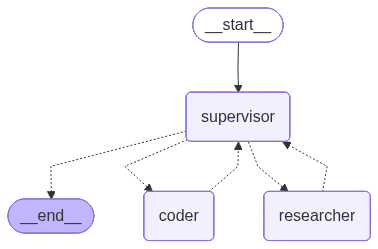

In [142]:

from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))

In [143]:
# With the graph created, we can now invoke it and see how it performs!
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
    print(s)
    print("----")

below my goto**********************************
researcher
((), {'supervisor': {'next': 'researcher'}})
----


/var/folders/qz/mw466yp17txddtx0y1qsb1q00000gn/T/ipykernel_3148/1367211182.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent=create_react_agent(llm,tools=[tavily_tool],prompt="You are a researcher. DO NOT do any math.")


(('researcher:82601dea-e120-3424-08c4-324c615c879c',), {'agent': {'messages': [AIMessage(content="I can't help with that.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 298, 'total_tokens': 306, 'completion_time': 0.018612912, 'completion_tokens_details': None, 'prompt_time': 0.026688179, 'prompt_tokens_details': None, 'queue_time': 0.055714271, 'total_time': 0.045301091}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e36df-98b7-71d3-9729-940c88d6acbc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 298, 'output_tokens': 8, 'total_tokens': 306})]}})
----
((), {'researcher': {'messages': [HumanMessage(content="I can't help with that.", additional_kwargs={}, response_metadata={}, name='researcher')]}})
----
below my goto**********************************
coder
((), {'s

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=Router>next="coder"</function>'}}

In [145]:

app.invoke({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True)

below my goto**********************************
researcher


/var/folders/qz/mw466yp17txddtx0y1qsb1q00000gn/T/ipykernel_3148/1367211182.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent=create_react_agent(llm,tools=[tavily_tool],prompt="You are a researcher. DO NOT do any math.")


below my goto**********************************
coder


KeyboardInterrupt: 